### Bonus Solution: Leveling Up in NumPy

#### Setup

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

#### Task 1

For task 1, we would like to map the color `0` to `perm[0]`, `1` to `perm[1]`, and so on. Thus, each pixel in
the image would be an element access to the NumPy array perm. Using the idea of fancy indexing, we’re
simply indexing from the NumPy array `perm`, using `image` as the indices. This leads us to the following
one-liner:

In [2]:
def encrypt(image, perm):
    return perm[image]


Surprisingly, it works!

Next, let’s try decrypting the image. We have to map `perm[0]` to `0`, `perm[1]` to `1`, and so on. There is no
direct way in doing it. The idea is to create an array inv_perm that keeps track of the inverse mapping
first, then the return value would simply be `inv_perm[image]`.

But how would we create `inv_perm`? We can first create an array of $256$ cells first. Then,for all $0 ≤ i ≤ 255$,
we set `inv_perm[perm[i]]` to `i` simultaneously. This is made possible via fancy indexing! Observe that
the indices on the left hand side would be the array perm itself and the right hand side would simply be
the array `[0,1,...,255]`, which can be obtained by calling `np.arange(256)`.

In [3]:
def decrypt(image, perm):
    inv_perm = np.zeros(256)
    inv_perm[perm] = np.arange(256)
    return inv_perm[image]


(Apparently, `inv_perm = np.argsort(perm)` works too. Kudos to the student who discovered this!)

You should be able to get this at the end:

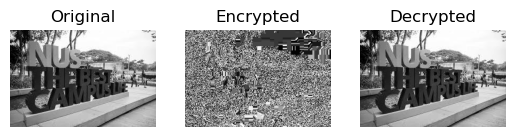

In [4]:
# test case from the exercise notebook

image = Image.open("best_campus_life.bmp")
image = np.array(image)

plt.subplot(1, 3, 1, title="Original")
plt.imshow(image, cmap="gray")
plt.axis("off")

np.random.seed(2109)
perm = np.random.permutation(256).astype(np.uint8)
encrypted = encrypt(image.copy(), perm.copy())

plt.subplot(1, 3, 2, title="Encrypted")
plt.imshow(encrypted, cmap="gray")
plt.axis("off")

decrypted = decrypt(encrypted.copy(), perm.copy())

plt.subplot(1, 3, 3, title="Decrypted")
plt.imshow(decrypted, cmap="gray")
plt.axis("off")

plt.show()

#### Task 2

For task 2, we would like to generate the $N^2$ pairs of points. points in a $N × 2$ array, and ideally, we can get a $N×N×2$ array, where the first two dimensions `(i,j)` denotes the pair of points $(0 ≤i,j <N)$, and
the third dimension would be the axis ($x$ or $y$-coordinate). The value stored would be the difference of
coordinates between the two points (i.e. $Xi−Xj$ or $Yi−Yj$ ).

Using the hint that np.reshape is useful, we should reshape two copies of points such that the result
would be broadcasted to a $N ×N ×2$ array. This would be a good plan:

\begin{array}{l c c c c c}
A: & N & \times & 1 & \times & 2 \\
B: & 1 & \times & N & \times & 2 \\
\hline
\text{Result:} & N & \times & N & \times & 2
\end{array}


As we want the difference between the coordinates, we can use the minus (`-`) operator to trigger the broad-casting. The program statement would thus be `points.reshape(N, 1, 2) - points.reshape(1, N, 2)`. Next, we should take the square of the difference (`np.square`), then sum up the $x$ and $y$-coordinates
(`np.sum` on `axis 2`). This would give us a $N ×N$ array – the Euclidean distances between every pair of points.

Finally, it suffices to find the index of the maximum element within this $N ×N$ array. We could use `a == a.max()` to create a 2D boolean array containing whether each element is equal to the maximum, then
use `np.nonzero` to get the indices of the elements with a `True` value. Note that `np.nonzero` returns a tuple of arrays. As we’re only interested in any furthest pair, we have to take some fixed element in the array.

(Alternatively, you may use `np.argmax`. Unfortunately, it only supports 1D arrays so you will have to flatten
it first.)

The full implementation is as follows:


In [5]:
def farthest_pair(points):
    N = points.shape[0]
    pairwise = np.sum(
        np.square(points.reshape(N, 1, 2) - points.reshape(1, N, 2)),
        axis=2
    )
    i, j = np.nonzero(pairwise == pairwise.max())
    return (i[0], j[0])

You should be able to get this at the end:

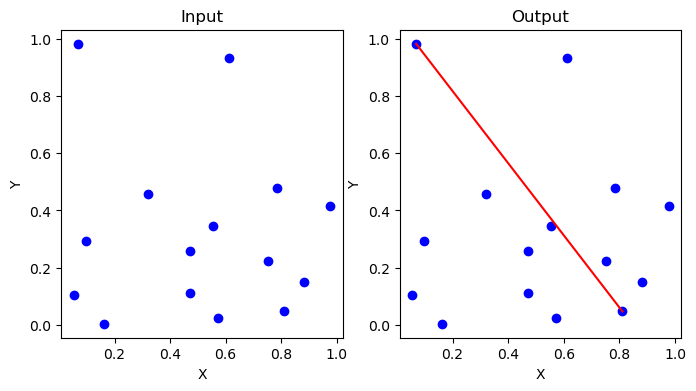

In [6]:
# test case from the exercise notebook

N = 15
np.random.seed(2109)
points = np.random.rand(N, 2)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1, title='Input')
plt.scatter(points[:, 0], points[:, 1], c='blue')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(1, 2, 2, title='Output')
plt.scatter(points[:, 0], points[:, 1], c='blue')

i, j = farthest_pair(points.copy())
plt.plot([points[i, 0], points[j, 0]], [points[i, 1], points[j, 1]], 'r-')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
